In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

f:\Langgraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class Operation(TypedDict):
    user_input: int
    positive: str 
    negative: str

In [3]:
def isPositive(state: Operation) -> Operation:
    return {"positive": "The given number is positive"}
    
    
def isNegative(state: Operation) -> Operation:
    # partial update of the state 
    return {"negative": "The given number is negative"}
    

# need to add node_name here as a return tyoe
def checkConditions(state: Operation) -> Literal["check_positive", "check_negative"]:
    if state["user_input"] >= 0:
        return "check_positive"
    return "check_negative"

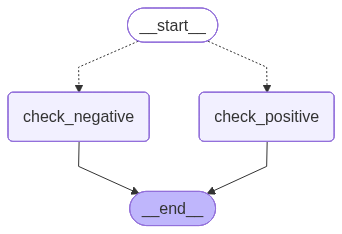

In [4]:
graph = StateGraph(Operation)

# node name and function
graph.add_node("check_positive", isPositive)
graph.add_node("check_negative", isNegative)

# we need to add conditional edges from which node to start
graph.add_conditional_edges(START, checkConditions)

# nodes used inside conditional branching needs to be added
graph.add_edge("check_positive", END)
graph.add_edge("check_negative", END)

workflow = graph.compile()
workflow

In [5]:
workflow.invoke({"user_input": -15})

{'user_input': -15, 'negative': 'The given number is negative'}

In [6]:
workflow.invoke({"user_input": 15})

{'user_input': 15, 'positive': 'The given number is positive'}